In [6]:
# import tensorflow as tf
# config = tf.compat.v1.ConfigProto()
# config.gpu_options.allow_growth = True
# session = tf.compat.v1.Session(config=config)

from tensorflow import keras
# print(tf.__version__)
# import os
# import tempfile
import joblib

# import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# import seaborn as sns

# from util import *
# from visualisation import *

# load calculated metrics

In [11]:
ara = pd.read_csv("../../data/features_screen/feat_arabidopsis.csv")
asgard = pd.read_csv("../../data/features_screen/feat_asgard.csv")
celegans = pd.read_csv("../../data/features_screen/feat_celegans.csv")
cyano = pd.read_csv("../../data/features_screen/feat_cyano.csv")
DPANN = pd.read_csv("../../data/features_screen/feat_DPANN.csv")
ecoli = pd.read_csv("../../data/features_screen/feat_ecoli.csv")
mus = pd.read_csv("../../data/features_screen/feat_mus.csv")
hum = pd.read_csv("../../data/features_screen/feat_homo.csv")
sacch = pd.read_csv("../../data/features_screen/feat_sacch.csv")
strep = pd.read_csv("../../data/features_screen/feat_strep.csv")

organism_datasets = {
    'arabidopsis': ara,
    'asgard': asgard, 
    'celegans': celegans,
    'cyano': cyano,
    'DPANN': DPANN,
    'ecoli': ecoli,
    'mus': mus,
    'human': hum,
    'sacch': sacch,
    'strep': strep
}

# classify structures

In [12]:
try:
    model_path = '../../predict/models/model_0.keras'
    model = keras.models.load_model(model_path)
except Exception as e:
    print(f"Error loading model: {str(e)}")
    raise

try:
    scaler = joblib.load("../../predict/code/scaler.pkl")
except Exception as e:
    print(f"Error loading scaler: {str(e)}")
    raise

all_results = {}

for organism_name, dataframe in organism_datasets.items():

    df_work = dataframe.copy()
    # test_y = np.array(df_work.pop('type'))
    name = np.array(df_work.pop('name'))

    feature_columns = ['-logP_Struc', '-logP_Contact', "area_sc", 'per_con', 'per_no_con', 'contact_order']
    X = np.array(df_work[feature_columns])
    X = scaler.transform(X)

    pred = model.predict(X, batch_size=32)

    result = []
    for prediction, name in zip(pred, name):
        result.append([prediction[0], name])


    # Convert to array and sort by score
    result = np.array(result)
    scores = result[:, 0].astype(float)
    sorted_indices = np.argsort(scores)[::-1]  # Sort descending
    sorted_data = result[sorted_indices]

    # Extract UniProt IDs from names
    names_col = sorted_data[:, 1]
    scores_col = sorted_data[:, 0].astype(float)

    # Extract UniProt IDs (assuming format like "something-UNIPROT_ID")
    uniprot_ids = []
    for name in names_col:
        try:
            uniprot_id = name.split('-')[1] if '-' in name else name
            uniprot_ids.append(uniprot_id)
        except IndexError:
            uniprot_ids.append(name)

    # Create results dataframe
    results_df = pd.DataFrame({
        'UniProtID': uniprot_ids,
        'scores': np.round(scores_col, 3)
    })
    
    all_results[organism_name] = results_df
    print(f"Predictions for {organism_name} completed.")


200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step
Predictions for arabidopsis completed.
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 0s 294us/step
Predictions for asgard completed.
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 405us/step
Predictions for celegans completed.
1744/1744 ━━━━━━━━━━━━━━━━━━━━ 1s 295us/step
Predictions for cyano completed.
3128/3128 ━━━━━━━━━━━━━━━━━━━━ 1s 292us/step
Predictions for DPANN completed.
919/919 ━━━━━━━━━━━━━━━━━━━━ 0s 301us/step
Predictions for ecoli completed.
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 320us/step
Predictions for mus completed.
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step
Predictions for human completed.
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step
Predictions for sacch completed.
4460/4460 ━━━━━━━━━━━━━━━━━━━━ 1s 285us/step
Predictions for strep completed.


In [10]:
info_ara = pd.read_csv("./info_ara.csv")
info_asgard = pd.read_csv("./info_asgard.csv")
# info_celegans = pd.read_csv("./info_celegans.csv")
info_cyano = pd.read_csv("./info_cyano.csv")
info_DPANN = pd.read_csv("./info_DPANN.csv")
# info_ecoli = pd.read_csv("./info_ecoli.csv")
# info_mus = pd.read_csv("./info_mus.csv")
# info_hum = pd.read_csv("./new_infoed_data_9606.csv")
info_sacch = pd.read_csv("./info_sacchmyc.csv")
info_strep = pd.read_csv("./info_strep.csv")

In [ ]:
# Map organism names to their info DataFrames
info_dfs = {
    'arabidopsis': info_ara,
    'asgard': info_asgard,
    # 'celegans': info_celegans,  # Uncomment if available
    'cyano': info_cyano,
    'DPANN': info_DPANN,
    # 'ecoli': info_ecoli,        # Uncomment if available
    # 'mus': info_mus,            # Uncomment if available
    # 'human': info_hum,          # Uncomment if available
    'sacch': info_sacch,
    'strep': info_strep
}

# Add Os, ID, Sequence columns from info DataFrames to results DataFrames
for organism, results_df in all_results.items():
    if (
        results_df is not None
        and not results_df.empty
        and organism in info_dfs
    ):
        info_df = info_dfs[organism]
        # Only merge if 'ID' exists in info_df and 'UniProtID' in results_df
        if 'id' in info_df.columns and 'UniProtID' in results_df.columns:
            merged = pd.merge(
                results_df,
                info_df[['OS', 'id', 'sequence']],
                left_on='UniProtID',
                right_on='id',
                how='left'
            )
            all_results[organism] = merged
        else:
            print(f"Skipping {organism}: required columns missing in info/results DataFrame.")

In [23]:
# Create plot for predicted data with scores > 0.5 (like graph.ipynb style)
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Process organism results with sequence information for plotting
if 'enhanced_results' in locals() and enhanced_results:
    plot_data = []
    
    # Dictionary mapping internal names to display names (like in graph.ipynb)
    name_mapping = {
        'arabidopsis': 'A. thaliana',
        'asgard': 'Asgard group', 
        'celegans': 'C. elegans',
        'cyano': 'Cyanobacteria',
        'DPANN': 'DPANN',
        'ecoli': 'E. coli',
        'mus': 'M. musculus',
        'human': 'H. sapiens',
        'sacch': 'S. cerevisiae',
        'strep': 'Streptomyces'
    }
    
    for organism_name, results_df in enhanced_results.items():
        if len(results_df) > 0:
            # Get original dataset size
            original_df = organism_datasets[organism_name]
            total_proteins = len(original_df)
            
            # Count predictions with score > 0.5
            high_score_predictions = len(results_df[results_df['scores'] > 0.5])
            all_predictions = len(results_df)
            
            # Count predictions with sequences available
            if 'sequence' in results_df.columns:
                high_score_with_seq = len(results_df[(results_df['scores'] > 0.5) & (results_df['sequence'].notna())])
                all_with_seq = len(results_df[results_df['sequence'].notna()])
            else:
                high_score_with_seq = 0
                all_with_seq = 0
            
            # Calculate percentages
            high_score_percentage = (high_score_predictions / total_proteins) * 100
            all_predictions_percentage = (all_predictions / total_proteins) * 100
            
            plot_data.append({
                'organism': name_mapping.get(organism_name, organism_name),
                'total_proteins': total_proteins,
                'all_predictions': all_predictions,
                'high_score_predictions': high_score_predictions,
                'high_score_percentage': high_score_percentage,
                'all_predictions_percentage': all_predictions_percentage,
                'high_score_with_seq': high_score_with_seq,
                'all_with_seq': all_with_seq,
                'seq_coverage': (all_with_seq / all_predictions * 100) if all_predictions > 0 else 0
            })
    
    # Convert to DataFrame
    plot_df = pd.DataFrame(plot_data)
    
    # Sort by high score percentage (descending)
    plot_df = plot_df.sort_values('high_score_percentage', ascending=False)
    
    print("Summary of denovo-like predictions with sequence information:")
    print(plot_df[['organism', 'total_proteins', 'high_score_predictions', 'high_score_percentage', 'high_score_with_seq', 'seq_coverage']].round(3))
    
elif 'all_results' in locals() and all_results:
    # Fallback to original results if enhanced results not available
    plot_data = []
    
    name_mapping = {
        'arabidopsis': 'A. thaliana',
        'asgard': 'Asgard group', 
        'celegans': 'C. elegans',
        'cyano': 'Cyanobacteria',
        'DPANN': 'DPANN',
        'ecoli': 'E. coli',
        'mus': 'M. musculus',
        'human': 'H. sapiens',
        'sacch': 'S. cerevisiae',
        'strep': 'Streptomyces'
    }
    
    for organism_name, results_df in all_results.items():
        if len(results_df) > 0:
            original_df = organism_datasets[organism_name]
            total_proteins = len(original_df)
            high_score_predictions = len(results_df[results_df['scores'] > 0.5])
            all_predictions = len(results_df)
            high_score_percentage = (high_score_predictions / total_proteins) * 100
            all_predictions_percentage = (all_predictions / total_proteins) * 100
            
            plot_data.append({
                'organism': name_mapping.get(organism_name, organism_name),
                'total_proteins': total_proteins,
                'all_predictions': all_predictions,
                'high_score_predictions': high_score_predictions,
                'high_score_percentage': high_score_percentage,
                'all_predictions_percentage': all_predictions_percentage
            })
    
    plot_df = pd.DataFrame(plot_data)
    plot_df = plot_df.sort_values('high_score_percentage', ascending=False)
    
    print("Summary of denovo-like predictions (no sequence info loaded):")
    print(plot_df[['organism', 'total_proteins', 'high_score_predictions', 'high_score_percentage']].round(3))
    
else:
    print("No results found. Please run the pipeline first.")
    plot_df = pd.DataFrame()

Summary of denovo-like predictions (no sequence info loaded):
        organism  total_proteins  high_score_predictions  \
4          DPANN          100308                    4492   
1   Asgard group           51236                    1889   
3  Cyanobacteria           56020                    1722   
9   Streptomyces            1404                      28   
5        E. coli           29637                     480   
6    M. musculus            8561                      78   
7     H. sapiens           13317                     102   
0    A. thaliana            6630                      45   
2     C. elegans            3337                      22   
8  S. cerevisiae            1485                       9   

   high_score_percentage  
4                  4.478  
1                  3.687  
3                  3.074  
9                  1.994  
5                  1.620  
6                  0.911  
7                  0.766  
0                  0.679  
2                  0.659  
8      

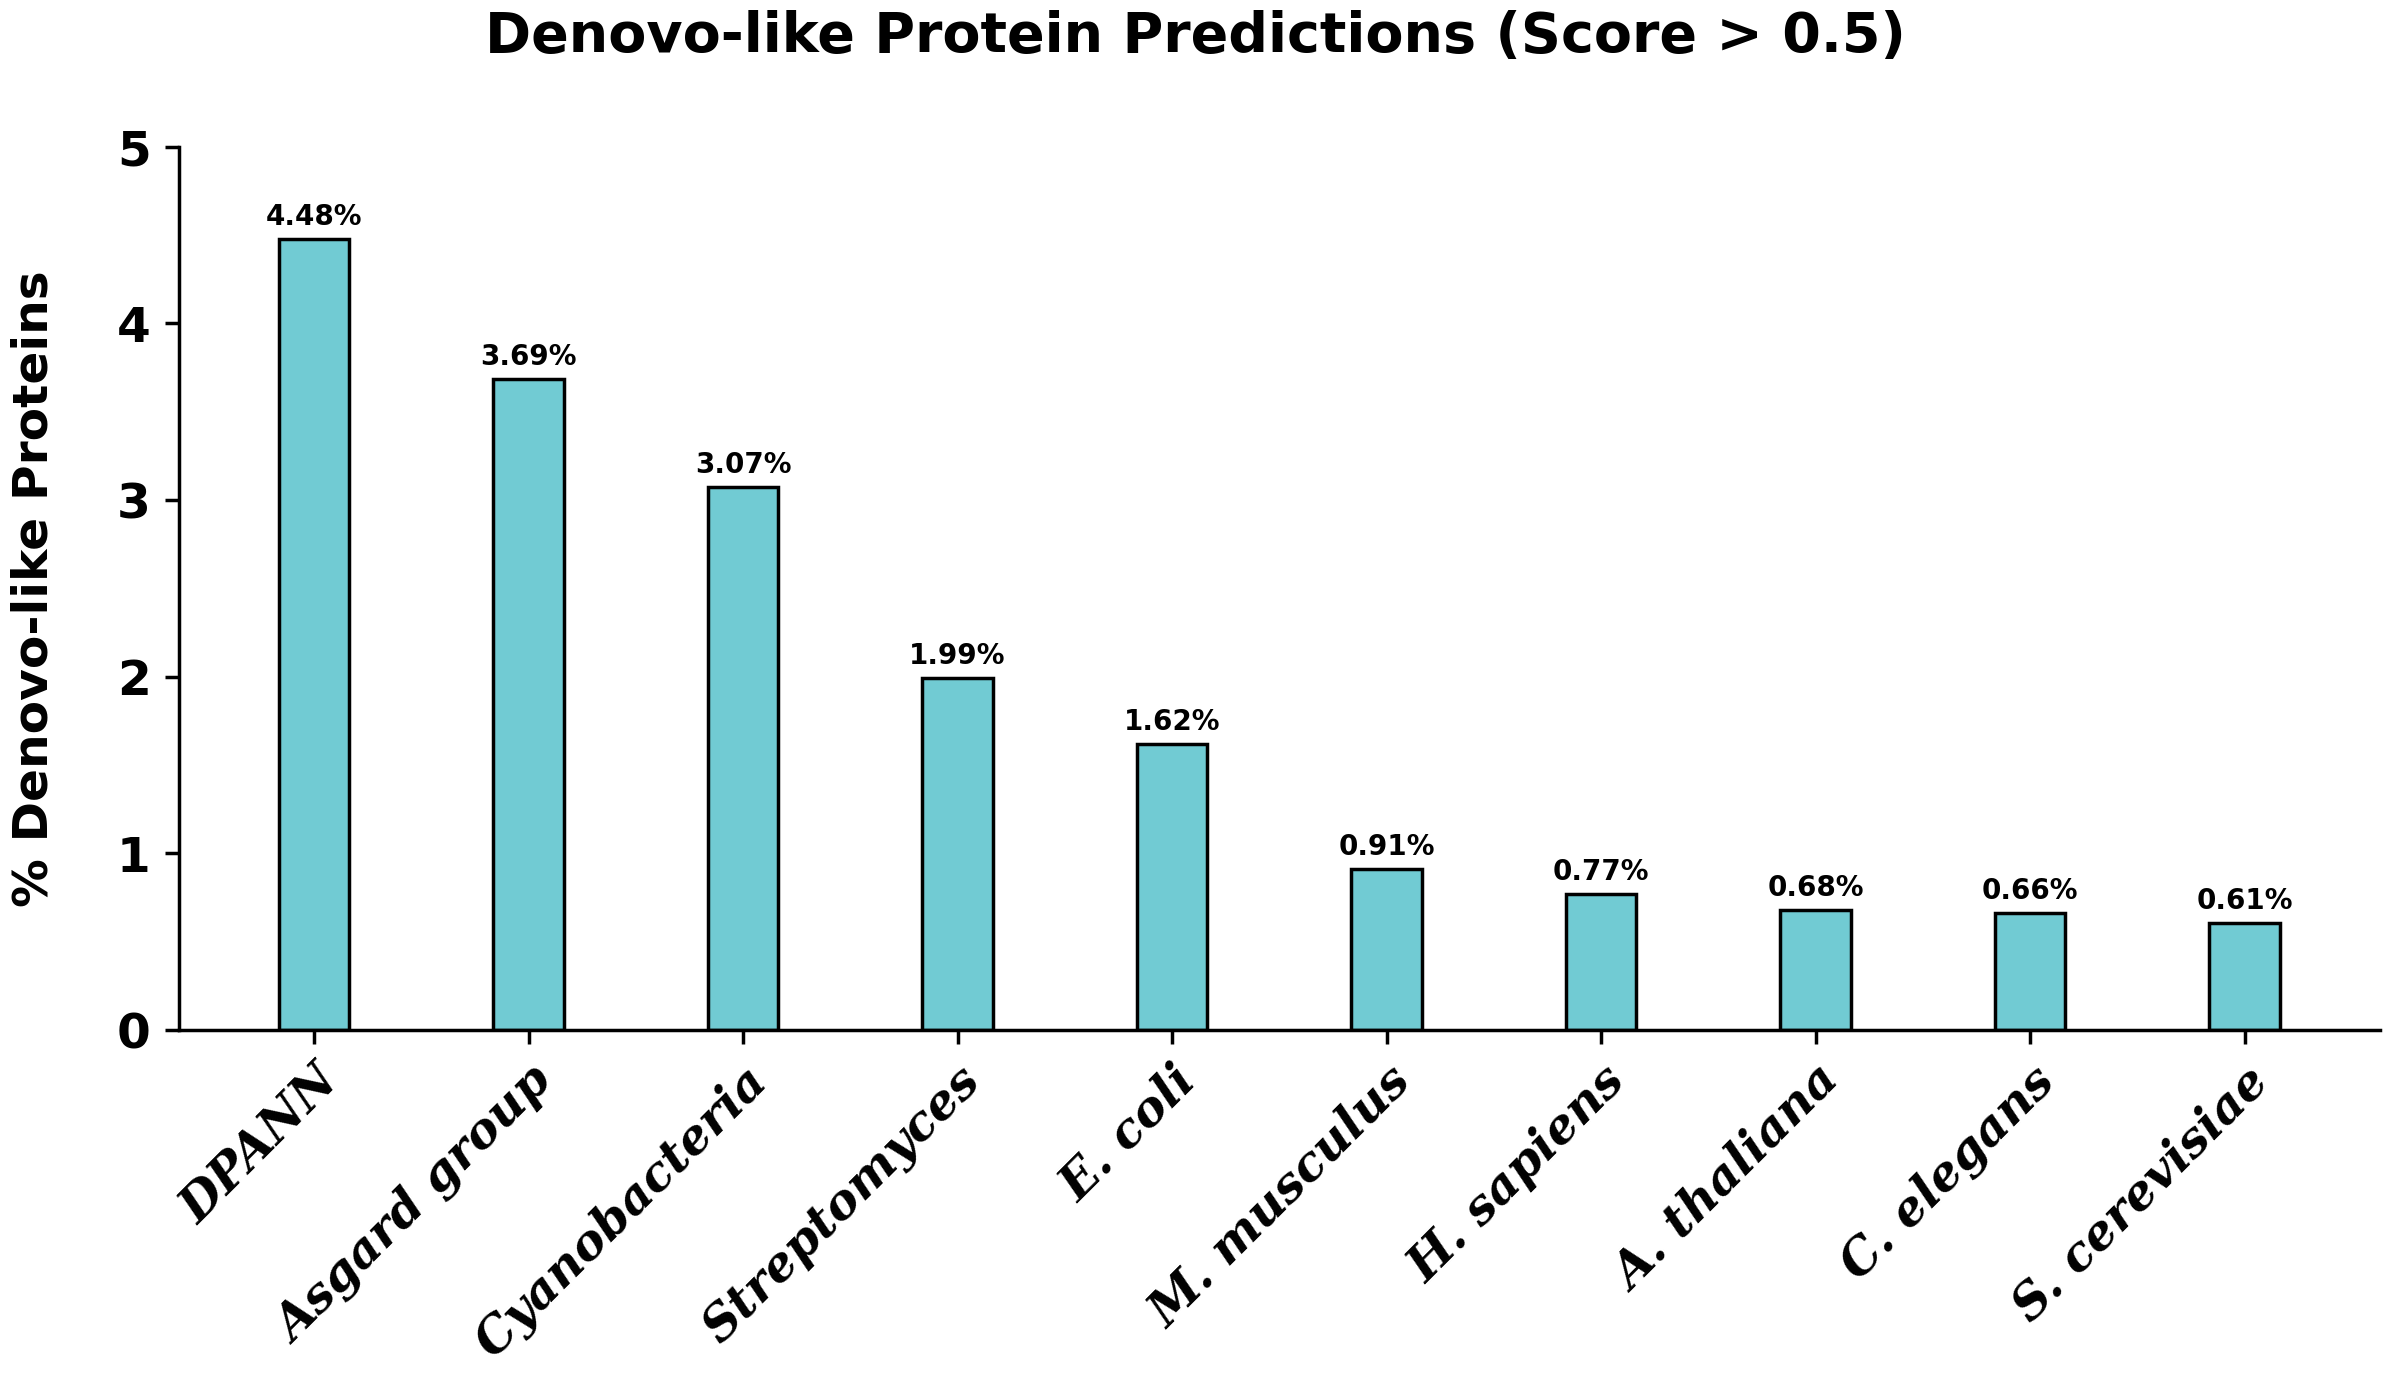


Summary Statistics:
Total OSs analyzed: 10
Average % denovo-like (score > 0.5): 1.847%
Highest % denovo-like: 4.478% (DPANN)
Lowest % denovo-like: 0.606% (S. cerevisiae)


In [27]:
# plot_df = all_results
# Create the plot in graph.ipynb style (second graph - single color)
if len(plot_df) > 0:
    # Style parameters (matching graph.ipynb)
    STD_COLOR = '0.0'
    kwargs_title = {'fontsize': 40, 'weight': 'bold', 'color': STD_COLOR}
    kwargs_label = {'fontsize': 35, 'weight': 'bold', 'color': STD_COLOR}
    kwargs_ticks = {'fontsize': 35, 'weight': 'bold', 'color': STD_COLOR}
    kwargs_plots = {'linewidth': 2.5, 'edgecolor': STD_COLOR, 'width': 0.33}
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(24, 14))
    
    # Bar plot with single color (like second graph in graph.ipynb)
    bars = ax.bar(plot_df['organism'], plot_df['high_score_percentage'], 
                  color='#71cbd3', **kwargs_plots)
    
    # Styling
    fig.suptitle("Denovo-like Protein Predictions (Score > 0.5)\n", **kwargs_title)
    ax.set_ylabel("% Denovo-like Proteins\n", **kwargs_label)
    
    # Set y-axis ticks and labels
    max_val = plot_df['high_score_percentage'].max()
    y_max = int(np.ceil(max_val / 5) * 5)  # Round up to nearest 5
    y_ticks = np.arange(0, y_max + 1, max(1, y_max // 10))
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{int(tick)}' for tick in y_ticks], **kwargs_ticks)
    
    # Set x-axis (matching second graph style with proper rotation)
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels([f'{name}' for name in plot_df['organism']], 
                       rotation=45, ha='right', rotation_mode='anchor',
                       fontdict={'fontfamily': 'serif', 'fontstyle': 'italic'}, 
                       **kwargs_label)
    
    # Spine styling
    for axis in ['bottom', 'left', 'top', 'right']:
        ax.spines[axis].set_linewidth(2.5)
        ax.spines[axis].set_color(STD_COLOR)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(width=2.5, length=10, pad=10, color=STD_COLOR)
    
    # Add value labels on top of bars (optional - remove if you prefer cleaner look)
    for i, (bar, value) in enumerate(zip(bars, plot_df['high_score_percentage'])):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + max_val*0.01,
                f'{value:.2f}%', ha='center', va='bottom',
                fontsize=20, weight='bold', color=STD_COLOR)
    
    plt.tight_layout()
    plt.savefig("./denovo_predictions_plot.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"Total OSs analyzed: {len(plot_df)}")
    print(f"Average % denovo-like (score > 0.5): {plot_df['high_score_percentage'].mean():.3f}%")
    print(f"Highest % denovo-like: {plot_df['high_score_percentage'].max():.3f}% ({plot_df.loc[plot_df['high_score_percentage'].idxmax(), 'organism']})")
    print(f"Lowest % denovo-like: {plot_df['high_score_percentage'].min():.3f}% ({plot_df.loc[plot_df['high_score_percentage'].idxmin(), 'organism']})")
    
else:
    print("No data available for plotting. Please run the pipeline first.")